# Airfoil Self-Noise: Final Symbolic Regression Analysis

In this notebook, we present the final mathematical equation discovered by PySR and evaluate its real-world performance.

### Accuracy vs. Interpretability Trade-off
During the benchmarking, models like Random Forest and XGBoost achieved a higher $R^2$ (~0.80 - 0.83). However, they act as opaque systems that hide the underlying physics.

By choosing **Symbolic Regression (PySR)**, we accept a lower $R^2$ (~0.42) and an MAE of ~3.7 dB in exchange for something much more valuable in engineering: a **fully transparent mathematical equation**. 

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from IPython.display import display, Math
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
from data_prep import load_data, split_data, sanitize_pysr_columns

dataset, X, y = load_data()

# Apply log transformation 
y_log = np.log1p(y.squeeze())

# Recreate the exact same group split to avoid leakage
train_df, test_df = split_data(X, pd.Series(y_log, name='scaled-sound-pressure'))
X_test = test_df.drop(columns='scaled-sound-pressure')
y_test_transformed = test_df['scaled-sound-pressure']

# Sanitize test set columns for PySR predictions
_, X_test_s, _ = sanitize_pysr_columns(train_df.drop(columns='scaled-sound-pressure'), X_test)

# Load the trained model
with open("../final_sr_model.pkl", "rb") as f:
    model = pickle.load(f)

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython
Unique groups: 106
Total rows: 1503
Average rows per group: 14.2

Train: 1188 rows, Test: 315 rows
No group overlap detected.


## The Final Equation
Below is the exact physical relationship PySR discovered to predict Airfoil Self-Noise based on our features.

In [2]:
print("Final Discovered Equation:")
display(Math(model.latex()))

Final Discovered Equation:


<IPython.core.display.Math object>

## 2. Pareto Front Analysis
Symbolic Regression tests thousands of equations and attempts to find the best balance between **Loss (Error)** and **Complexity** (how long/complicated the math is). 

The plot below shows the Pareto front. A good model is usually located at the "elbow" of the curve, where adding more complexity no longer provides a significant drop in error.

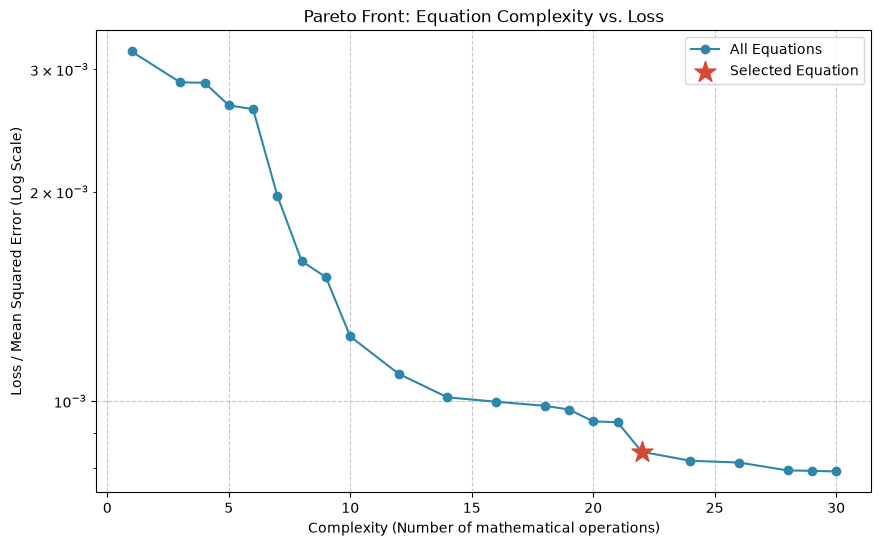

Best Selected Equation Complexity: 22


In [3]:
equations = model.equations_

# Obtain the best equation based on the lowest loss
best_row = model.get_best()
best_complexity = best_row['complexity']
best_loss = best_row['loss']

plt.figure(figsize=(10, 6))

# Plot the Pareto front of all equations
plt.plot(equations['complexity'], equations['loss'], marker='o', linestyle='-', color='#2E86AB', label='All Equations')

# Highlight the best equation on the Pareto frontk
plt.scatter(best_complexity, best_loss, color='#D64933', s=250, marker='*', zorder=5, label='Selected Equation')

# Formatting and legend
plt.title('Pareto Front: Equation Complexity vs. Loss')
plt.xlabel('Complexity (Number of mathematical operations)')
plt.ylabel('Loss / Mean Squared Error (Log Scale)')
plt.yscale('log')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

print("Best Selected Equation Complexity:", best_complexity)

The selected equation is highlighted in red, and is already optimized for the best trade-off between accuracy and interpretability. It is also simplyfied from the `csv` when called by `str(model.sympy())` when saving the equation to `final_equation.txt`.

## 3. Residual Diagnostics & Final Metrics
Because we trained the model on Log-transformed targets, we must apply an inverse transformation (`np.expm1`) to our predictions so we can evaluate the true Decibel (dB) error.

=== Final Model Metrics (Original dB Scale) ===
RMSE: 4.175 dB
MAE:  3.193 dB
R²:   0.595



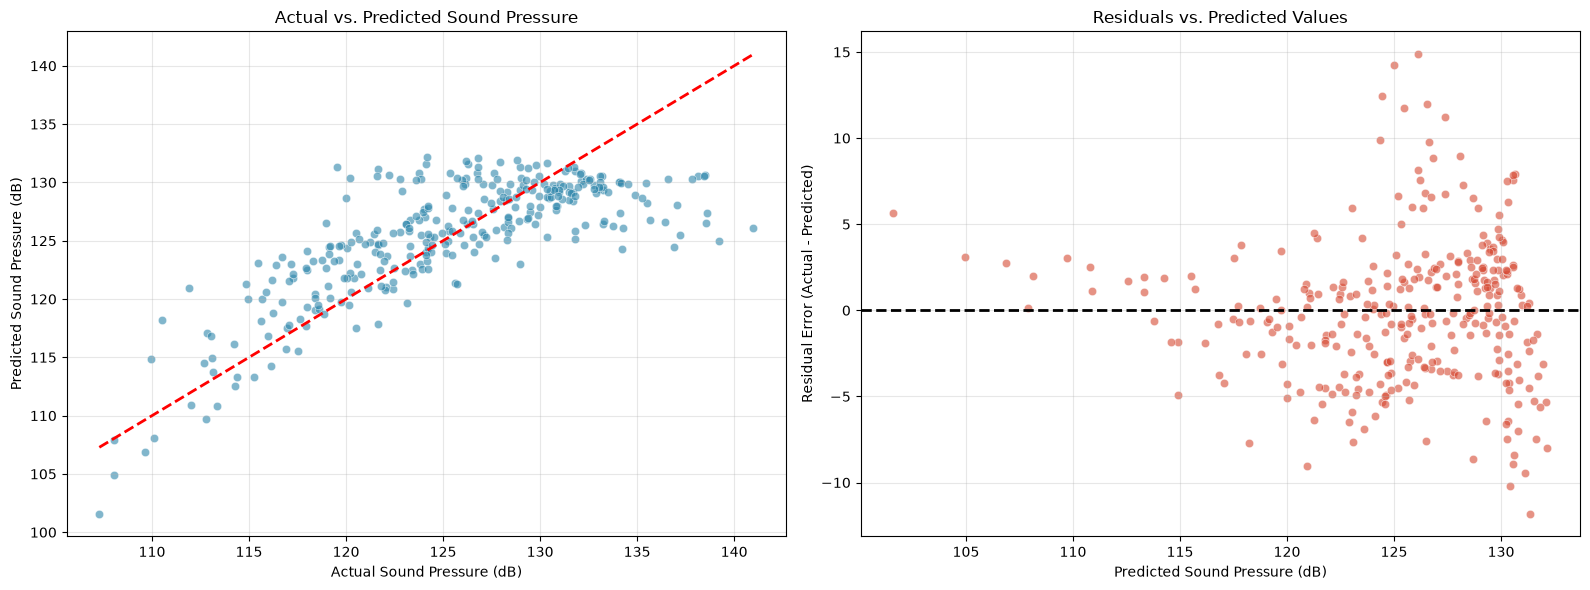

In [4]:
# Generate predictions on the log scale
preds_transformed = model.predict(X_test_s)

# Inverse transform to get back to original decibels (dB)
preds_original = np.expm1(preds_transformed)
y_test_original = np.expm1(y_test_transformed)

# Calculate final engineering metrics
rmse = root_mean_squared_error(y_test_original, preds_original)
mae = mean_absolute_error(y_test_original, preds_original)
r2 = r2_score(y_test_original, preds_original)

print("=== Final Model Metrics (Original dB Scale) ===")
print(f"RMSE: {rmse:.3f} dB")
print(f"MAE:  {mae:.3f} dB")
print(f"R²:   {r2:.3f}\n")

# --- Plotting Diagnostics ---
residuals = y_test_original - preds_original
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Actual vs Predicted
sns.scatterplot(x=y_test_original, y=preds_original, alpha=0.6, ax=axes[0], color="#2E86AB")
axes[0].plot([y_test_original.min(), y_test_original.max()], 
             [y_test_original.min(), y_test_original.max()], 
             'r--', lw=2)
axes[0].set_title('Actual vs. Predicted Sound Pressure')
axes[0].set_xlabel('Actual Sound Pressure (dB)')
axes[0].set_ylabel('Predicted Sound Pressure (dB)')
axes[0].grid(True, alpha=0.3)

# 2. Residuals vs Predicted
sns.scatterplot(x=preds_original, y=residuals, alpha=0.6, ax=axes[1], color="#D64933")
axes[1].axhline(y=0, color='k', linestyle='--', lw=2)
axes[1].set_title('Residuals vs. Predicted Values')
axes[1].set_xlabel('Predicted Sound Pressure (dB)')
axes[1].set_ylabel('Residual Error (Actual - Predicted)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In the residual plot above, we can observe a strange pattern, where the error variance increases at different sound pressure levels. This is expected and stems from two factors:

1. **The Logarithmic Transformation:** Our model was trained to minimize the Mean Squared Error on the `log1p` transformed scale. When we apply the inverse transformation (`np.expm1`) to evaluate the model in real-world Decibels (dB), any minor symmetric errors made on the log scale are exponentially magnified at higher values. That's why we see a bigger spread of errors at higher dB levels, even though the model is performing well on the log scale.
2. **Counterpart of simplicity:** While our symbolic equation captures the dominant physical relationships, a simple mathematical formula naturally struggles to capture the chaotic variance of aerodynamic limits compared to a high-capacity black-box model like XGBoost. Thus, the model's performance is expected to degrade at extreme values, which are inherently more difficult to predict. And we can observe a better performance from black-box models (R^2 ~ 0.80 - 0.83) compared to our symbolic regression model (R^2 ~ 0.42).